In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

df = pd.read_csv('ford.csv')
print(f"Размер датасета: {df.shape}")
df.head()

Размер датасета: (17966, 9)


,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [3]:
null_cols = ['year', 'mileage', 'tax', 'mpg', 'engineSize']
for col in null_cols:
    nan_indices = np.random.choice(df.index, size=150, replace=False)
    df.loc[nan_indices, col] = np.nan


In [4]:
print("Количество пропусков по столбцам:")
print(df.isnull().sum())
print("\nКоличество дубликатов (полных):", df.duplicated().sum())


Количество пропусков по столбцам:
model             0
year            150
price             0
transmission      0
mileage         150
fuelType          0
tax             150
mpg             150
engineSize      150
dtype: int64

Количество дубликатов (полных): 142


In [5]:
def zscore(data, threshold=3):
    z_scores = np.abs(stats.zscore(data))
    outliers = data[z_scores > threshold]
    return outliers

outliers = zscore(df['price'])
print(f"Найдено выбросов: {len(outliers)}")

Найдено выбросов: 171


In [6]:
print(f"Типы данных:\n{df.dtypes}")

Типы данных:
model            object
year            float64
price             int64
transmission     object
mileage         float64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
dtype: object


In [7]:
print(f'Уникальные значения моделей: {df['model'].unique()}')
print(f'Уникальные значения трансмиссии: {df['transmission'].unique()}')
print(f'Уникальные значения типа двигателя: {df['fuelType'].unique()}')

Уникальные значения моделей: [' Fiesta' ' Focus' ' Puma' ' Kuga' ' EcoSport' ' C-MAX' ' Mondeo' ' Ka+'
 ' Tourneo Custom' ' S-MAX' ' B-MAX' ' Edge' ' Tourneo Connect'
 ' Grand C-MAX' ' KA' ' Galaxy' ' Mustang' ' Grand Tourneo Connect'
 ' Fusion' ' Ranger' ' Streetka' ' Escort' ' Transit Tourneo' 'Focus']
Уникальные значения трансмиссии: ['Automatic' 'Manual' 'Semi-Auto']
Уникальные значения типа двигателя: ['Petrol' 'Diesel' 'Hybrid' 'Electric' 'Other']


In [8]:
print('ВЫЧИСЛЕНИЕ БАЗОВЫХ ХАРАКТЕРИСТИК ДЛЯ ЧИСЛОВЫХ ПРИЗНАКОВ')

print(f'Медианы:')
print(f'\tyear: {df['year'].median()}')
print(f'\tprice: {df['price'].median()}')
print(f'\tmileage: {df['mileage'].median()}')
print(f'\ttax: {df['tax'].median()}')
print(f'\tmpg: {df['mpg'].median()}')
print(f'\tengineSize: {df['engineSize'].median()}')

print(f'Минимумы:')
print(f'\tyear: {df['year'].min()}')
print(f'\tprice: {df['price'].min()}')
print(f'\tmileage: {df['mileage'].min()}')
print(f'\ttax: {df['tax'].min()}')
print(f'\tmpg: {df['mpg'].min()}')
print(f'\tengineSize: {df['engineSize'].min()}')

print(f'Максимумы:')
print(f'\tyear: {df['year'].max()}')
print(f'\tprice: {df['price'].max()}')
print(f'\tmileage: {df['mileage'].max()}')
print(f'\ttax: {df['tax'].max()}')
print(f'\tmpg: {df['mpg'].max()}')
print(f'\tengineSize: {df['engineSize'].max()}')

print(f'СКО:')
print(f'\tyear: {df['year'].std():.4f}')
print(f'\tprice: {df['price'].std():.4f}')
print(f'\tmileage: {df['mileage'].std():.4f}')
print(f'\ttax: {df['tax'].std():.4f}')
print(f'\tmpg: {df['mpg'].std():.4f}')
print(f'\tengineSize: {df['engineSize'].std():.4f}')

ВЫЧИСЛЕНИЕ БАЗОВЫХ ХАРАКТЕРИСТИК ДЛЯ ЧИСЛОВЫХ ПРИЗНАКОВ
Медианы:
	year: 2017.0
	price: 11291.0
	mileage: 18250.0
	tax: 145.0
	mpg: 58.9
	engineSize: 1.2
Минимумы:
	year: 1996.0
	price: 495
	mileage: 1.0
	tax: 0.0
	mpg: 20.8
	engineSize: 0.0
Максимумы:
	year: 2060.0
	price: 54995
	mileage: 177644.0
	tax: 580.0
	mpg: 201.8
	engineSize: 5.0
СКО:
	year: 2.0497
	price: 4741.3437
	mileage: 19496.4436
	tax: 61.9955
	mpg: 10.1286
	engineSize: 0.4328


In [9]:
freq_model = df['model'].value_counts()
freq_transmission = df['transmission'].value_counts()
freq_fuelType = df['fuelType'].value_counts()

print('Частоты значений:')
print(freq_model, freq_transmission, freq_fuelType, sep = '\n' + '-' * 30 + '\n')

Частоты значений:
model
 Fiesta                   6557
 Focus                    4588
 Kuga                     2225
 EcoSport                 1143
 C-MAX                     543
 Ka+                       531
 Mondeo                    526
 B-MAX                     355
 S-MAX                     296
 Grand C-MAX               247
 Galaxy                    228
 Edge                      208
 KA                        199
 Puma                       80
 Tourneo Custom             69
 Grand Tourneo Connect      59
 Mustang                    57
 Tourneo Connect            33
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64
------------------------------
transmission
Manual       15518
Automatic     1361
Semi-Auto     1087
Name: count, dtype: int64
------------------------------
fuelType
Petrol      12179
Diesel       5762
Hyb

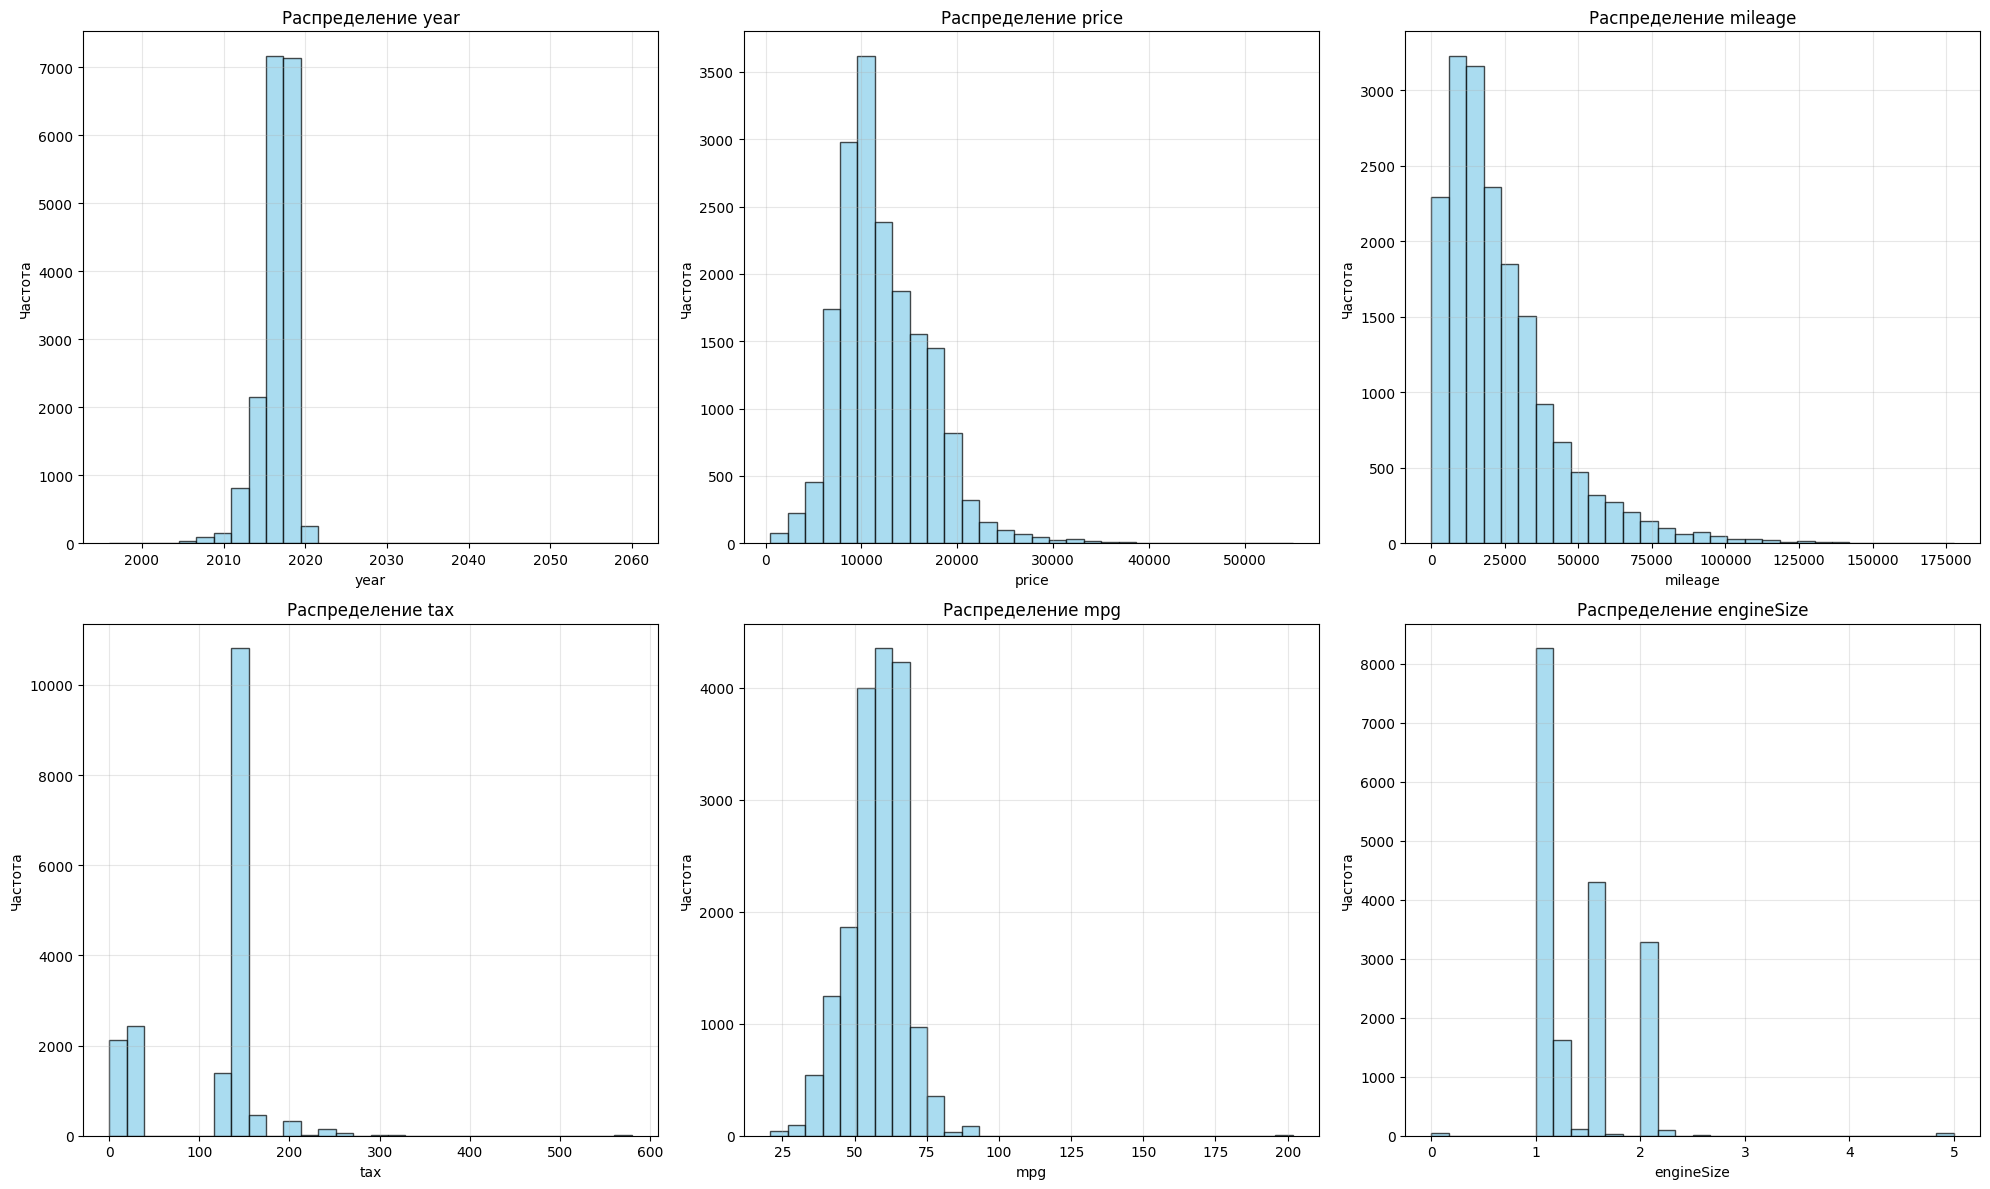

In [10]:
columns = ['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize']

plt.figure(figsize=(20, 12))
for i, column in enumerate(columns):
    plt.subplot(2, 3, i + 1)
    plt.hist(df[column], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    plt.xlabel(column)
    plt.ylabel('Частота')
    plt.title(f'Распределение {column}')
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

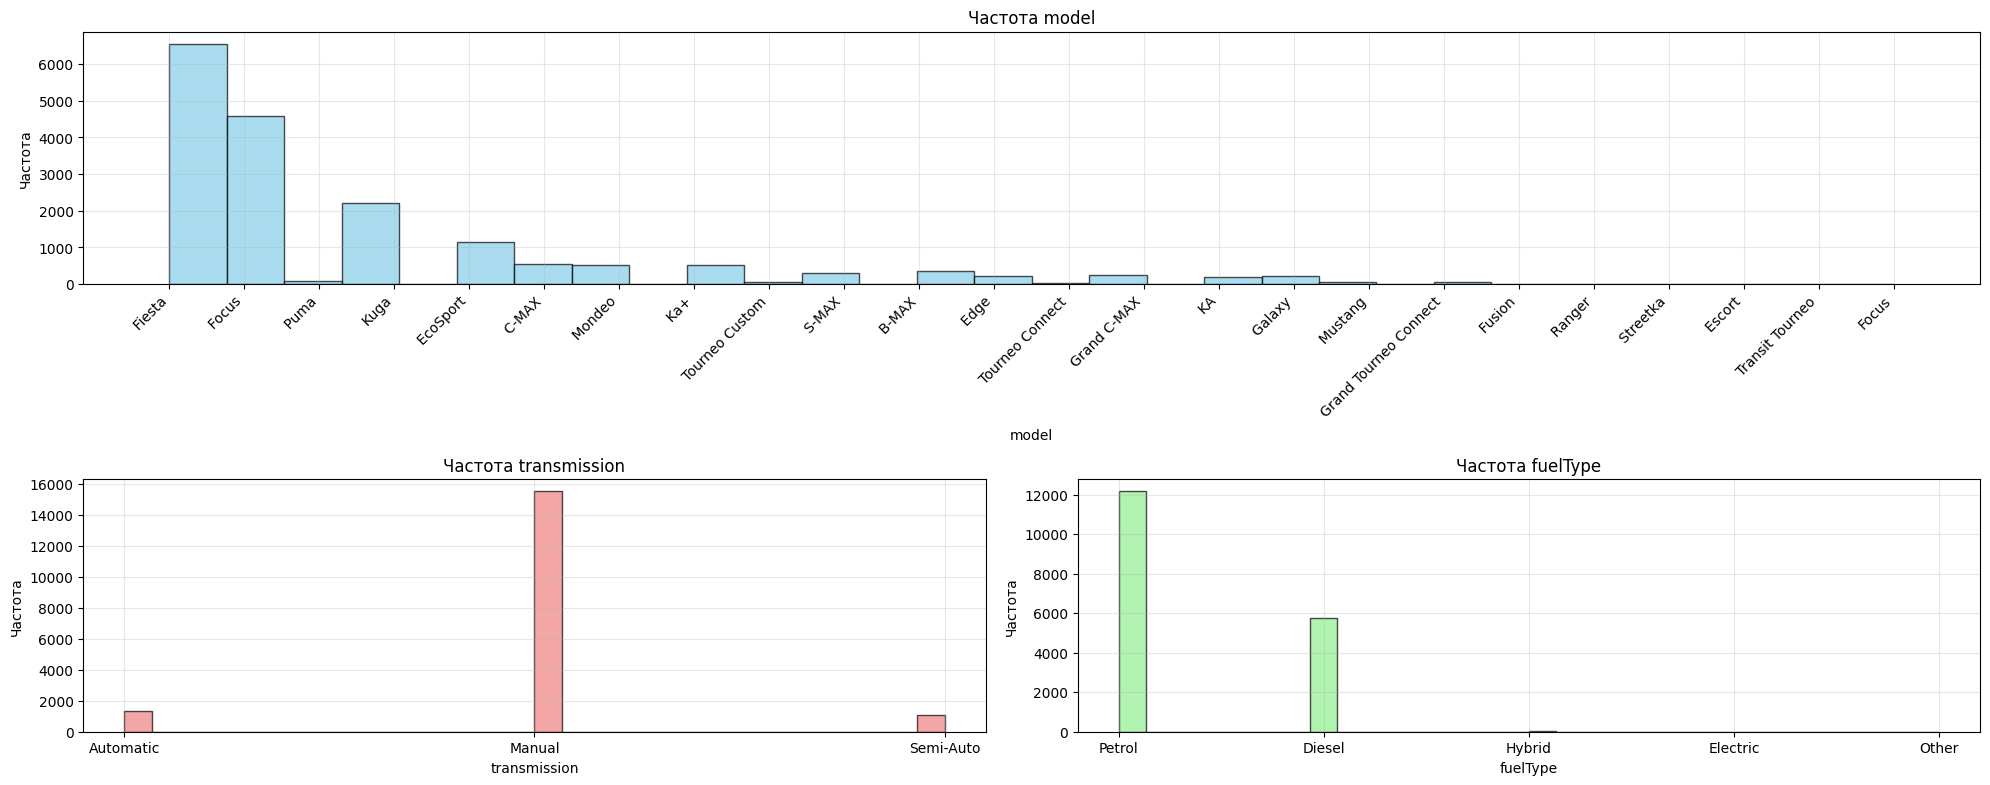

In [11]:
columns = ['model', 'transmission', 'fuelType']
plt.figure(figsize=(20, 12))

plt.subplot2grid((3, 1), (0, 0), colspan=1)
plt.hist(df['model'], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('model')
plt.ylabel('Частота')
plt.title('Частота model')
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)

plt.subplot2grid((3, 2), (1, 0), colspan=1)
plt.hist(df['transmission'], bins=30, alpha=0.7, color='lightcoral', edgecolor='black')
plt.xlabel('transmission')
plt.ylabel('Частота')
plt.title('Частота transmission')
plt.grid(alpha=0.3)

plt.subplot2grid((3, 2), (1, 1), colspan=1)
plt.hist(df['fuelType'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
plt.xlabel('fuelType')
plt.ylabel('Частота')
plt.title('Частота fuelType')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
full_duplicates = df[df.duplicated()]
print(f"Полные дубликаты: {len(full_duplicates)}")

partial_duplicates = df[df.duplicated(subset=['model', 'year', 'mileage', 'price'], keep=False)]
print(f"Частичные дубликаты: {len(partial_duplicates)}")

initial_count = len(df)
df_clean = df.drop_duplicates()
final_count = len(df_clean)
print(f"Удалено дубликатов: {initial_count - final_count}")

Полные дубликаты: 142
Частичные дубликаты: 370
Удалено дубликатов: 142


In [13]:
print("Пропуски до обработки:")
print(df_clean.isnull().sum())

for column in null_cols:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

print("\nПропуски после обработки:")
print(df_clean.isnull().sum())

Пропуски до обработки:
model             0
year            150
price             0
transmission      0
mileage         149
fuelType          0
tax             150
mpg             150
engineSize      150
dtype: int64

Пропуски после обработки:
model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64


C:\Users\Пользователь\AppData\Local\Temp\ipykernel_9396\3346109048.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[column] = df_clean[column].fillna(df_clean[column].median())
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_9396\3346109048.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[column] = df_clean[column].fillna(df_clean[column].median())
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_9396\3346109048.py:5: SettingWithCopyWarning: 
A value is trying to be set on a cop

In [14]:
import category_encoders as ce

print("Кардинальность категориальных признаков:")
print(f"model: {df['model'].nunique()} уникальных значений")
print(f"transmission: {df['transmission'].nunique()} уникальных значений")
print(f"fuelType: {df['fuelType'].nunique()} уникальных значений")

def encode_categorical_features(df):
    df_encoded = df.copy()
    
    target_encoder = ce.TargetEncoder(cols=['model'])
    df_encoded['model_encoded'] = target_encoder.fit_transform(df_encoded['model'], df_encoded['price'])
    
    transmission_encoded = pd.get_dummies(df_encoded['transmission'], prefix='transmission')
    df_encoded = pd.concat([df_encoded, transmission_encoded], axis=1)
    
    fuel_mapping = {'Petrol': 0, 'Diesel': 1, 'Hybrid': 2, 'Electric': 3, 'Other': 4}
    df_encoded['fuelType_encoded'] = df_encoded['fuelType'].map(fuel_mapping)
    
    df_encoded = df_encoded.drop(['model', 'transmission', 'fuelType'], axis=1)
    
    return df_encoded

df_encoded = encode_categorical_features(df_clean)
print("Категориальные признаки закодированы")

Кардинальность категориальных признаков:
model: 24 уникальных значений
transmission: 3 уникальных значений
fuelType: 5 уникальных значений
Категориальные признаки закодированы


In [15]:
df_encoded.head()

,year,price,mileage,tax,mpg,engineSize,model_encoded,transmission_Automatic,transmission_Manual,transmission_Semi-Auto,fuelType_encoded
0,2017.0,12000,15944.0,150.0,57.7,1.0,10190.888667,True,False,False,0
1,2018.0,14000,9083.0,150.0,57.7,1.0,13182.976969,False,True,False,0
2,2017.0,13000,12456.0,150.0,57.7,1.0,13182.976969,False,True,False,0
3,2019.0,17500,10460.0,145.0,40.3,1.5,10190.888667,False,True,False,0
4,2019.0,16500,1482.0,145.0,48.7,1.0,10190.888667,True,False,False,0



--- Анализ выбросов для price ---
Выбросы в price: 282 (1.58%)


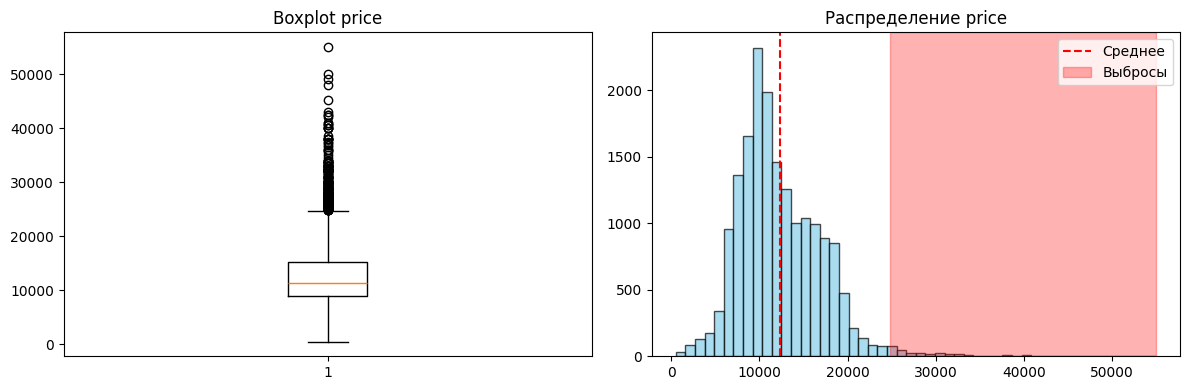


--- Анализ выбросов для mileage ---
Выбросы в mileage: 870 (4.88%)


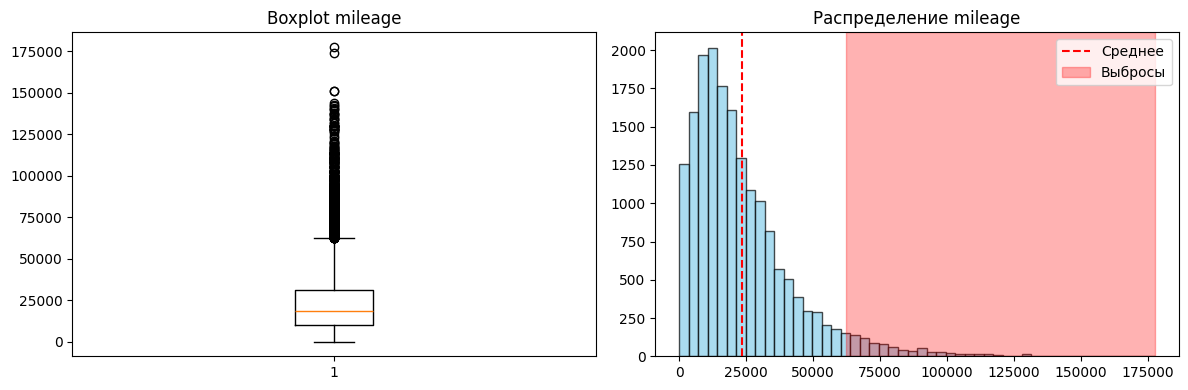


--- Анализ выбросов для year ---
Выбросы в year: 494 (2.77%)


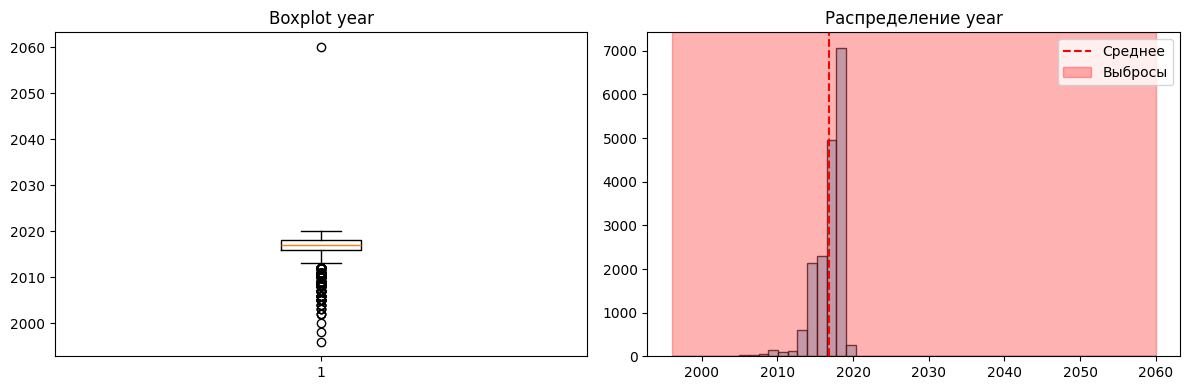


--- Анализ выбросов для tax ---
Выбросы в tax: 19 (0.11%)


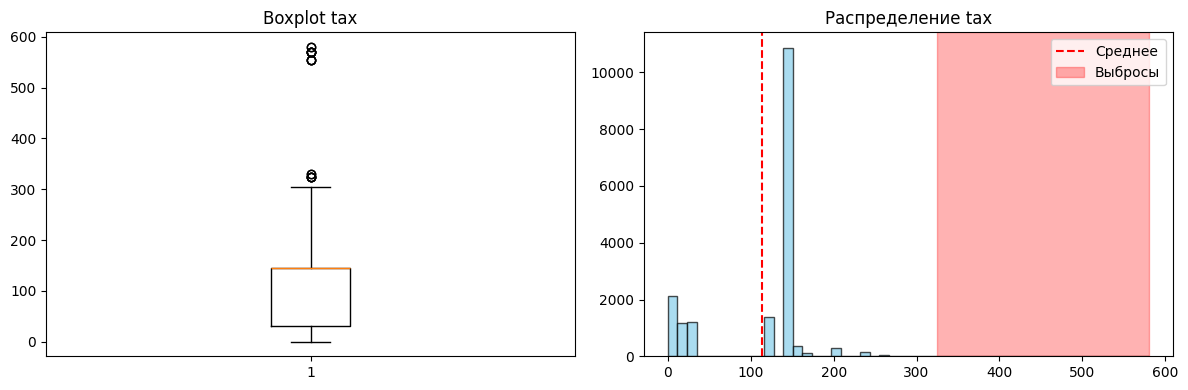


--- Анализ выбросов для mpg ---
Выбросы в mpg: 215 (1.21%)


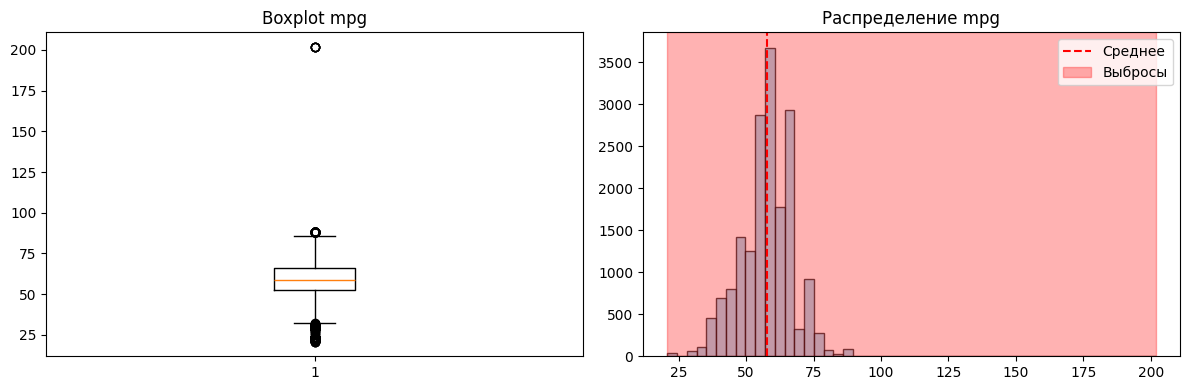


--- Анализ выбросов для engineSize ---
Выбросы в engineSize: 190 (1.07%)


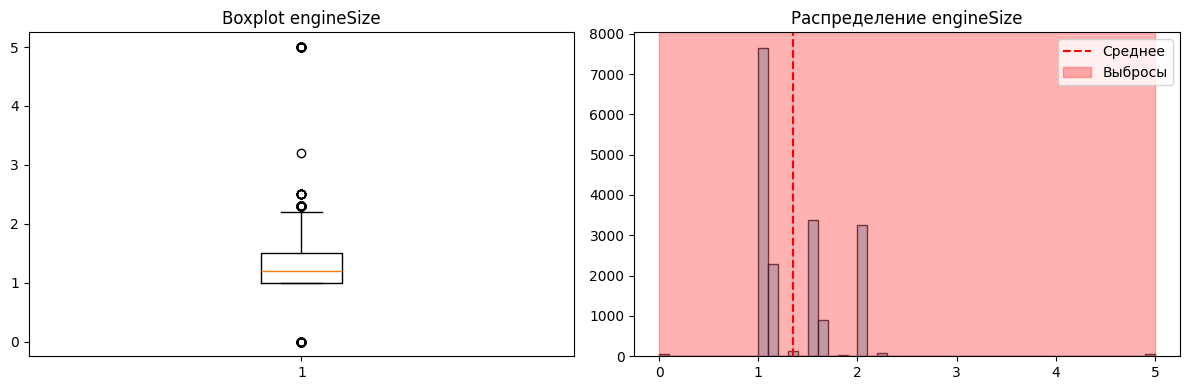

In [16]:
def outliers(df, column, method='iqr'):
    data = df[column].copy()
    
    if method == 'iqr':
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_mask = (data < lower_bound) | (data > upper_bound)
        
    elif method == 'zscore':
        z_scores = np.abs(stats.zscore(data))
        outliers_mask = z_scores > 3
    
    print(f"Выбросы в {column}: {outliers_mask.sum()} ({outliers_mask.mean():.2%})")
    
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.boxplot(data)
    plt.title(f'Boxplot {column}')
    
    plt.subplot(1, 2, 2)
    plt.hist(data, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    plt.axvline(data.mean(), color='red', linestyle='--', label='Среднее')
    if outliers_mask.any():
        plt.axvspan(data[outliers_mask].min(), data[outliers_mask].max(), 
                alpha=0.3, color='red', label='Выбросы')
    plt.title(f'Распределение {column}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    if outliers_mask.any():
        lower_percentile = data.quantile(0.01)
        upper_percentile = data.quantile(0.99)
        data_clean = np.clip(data, lower_percentile, upper_percentile)
        return data_clean, outliers_mask
    else:
        return data, outliers_mask

numeric_columns = ['price', 'mileage', 'year', 'tax', 'mpg', 'engineSize']
outliers_info = {}

for column in numeric_columns:
    print(f"\n--- Анализ выбросов для {column} ---")
    df_encoded[f'{column}_clean'], outliers_info[column] = outliers(
        df_encoded, column, method='iqr'
    )

In [17]:
from sklearn.preprocessing import StandardScaler, PowerTransformer, RobustScaler

def analyze_skewness_and_scale(df, columns):
    """
    Анализ асимметрии и выбор масштабирования
    """
    skewness_results = {}
    
    for column in columns:
        original_skew = df[column].skew()
        skewness_results[column] = original_skew
        
        print(f"{column}:")
        print(f"  Асимметрия: {original_skew:.4f}")
        
        # Выбор метода масштабирования на основе асимметрии
        if abs(original_skew) < 0.5:
            print("  Рекомендация: StandardScaler (распределение близко к нормальному)")
            scaler = StandardScaler()
        elif abs(original_skew) < 2:
            print("  Рекомендация: PowerTransformer (умеренная асимметрия)")
            scaler = PowerTransformer(method='yeo-johnson')
        else:
            print("  Рекомендация: RobustScaler + логарифмирование (сильная асимметрия)")
            # Сначала логарифмируем, потом RobustScaler
            df[f'{column}_log'] = np.log1p(df[column])
            scaler = RobustScaler()
        
        # Применяем масштабирование
        scaled_data = scaler.fit_transform(df[[column]])
        df[f'{column}_scaled'] = scaled_data
        
        print(f"  Асимметрия после преобразования: {df[f'{column}_scaled'].skew():.4f}")
        print()
    
    return skewness_results, df

skewness_results, df_scaled = analyze_skewness_and_scale(df_encoded, numeric_columns)

price:
  Асимметрия: 1.0965
  Рекомендация: PowerTransformer (умеренная асимметрия)
  Асимметрия после преобразования: 0.0550

mileage:
  Асимметрия: 1.8425
  Рекомендация: PowerTransformer (умеренная асимметрия)
  Асимметрия после преобразования: 0.0373

year:
  Асимметрия: -1.2803
  Рекомендация: PowerTransformer (умеренная асимметрия)
  Асимметрия после преобразования: 0.6385

tax:
  Асимметрия: -0.5736
  Рекомендация: PowerTransformer (умеренная асимметрия)
  Асимметрия после преобразования: -0.8166

mpg:
  Асимметрия: 0.6128
  Рекомендация: PowerTransformer (умеренная асимметрия)
  Асимметрия после преобразования: 0.1897

engineSize:
  Асимметрия: 1.9224
  Рекомендация: PowerTransformer (умеренная асимметрия)
  Асимметрия после преобразования: -0.0989



c:\Users\Пользователь\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\_core\_methods.py:197: RuntimeWarning: overflow encountered in multiply
  x = um.multiply(x, x, out=x)


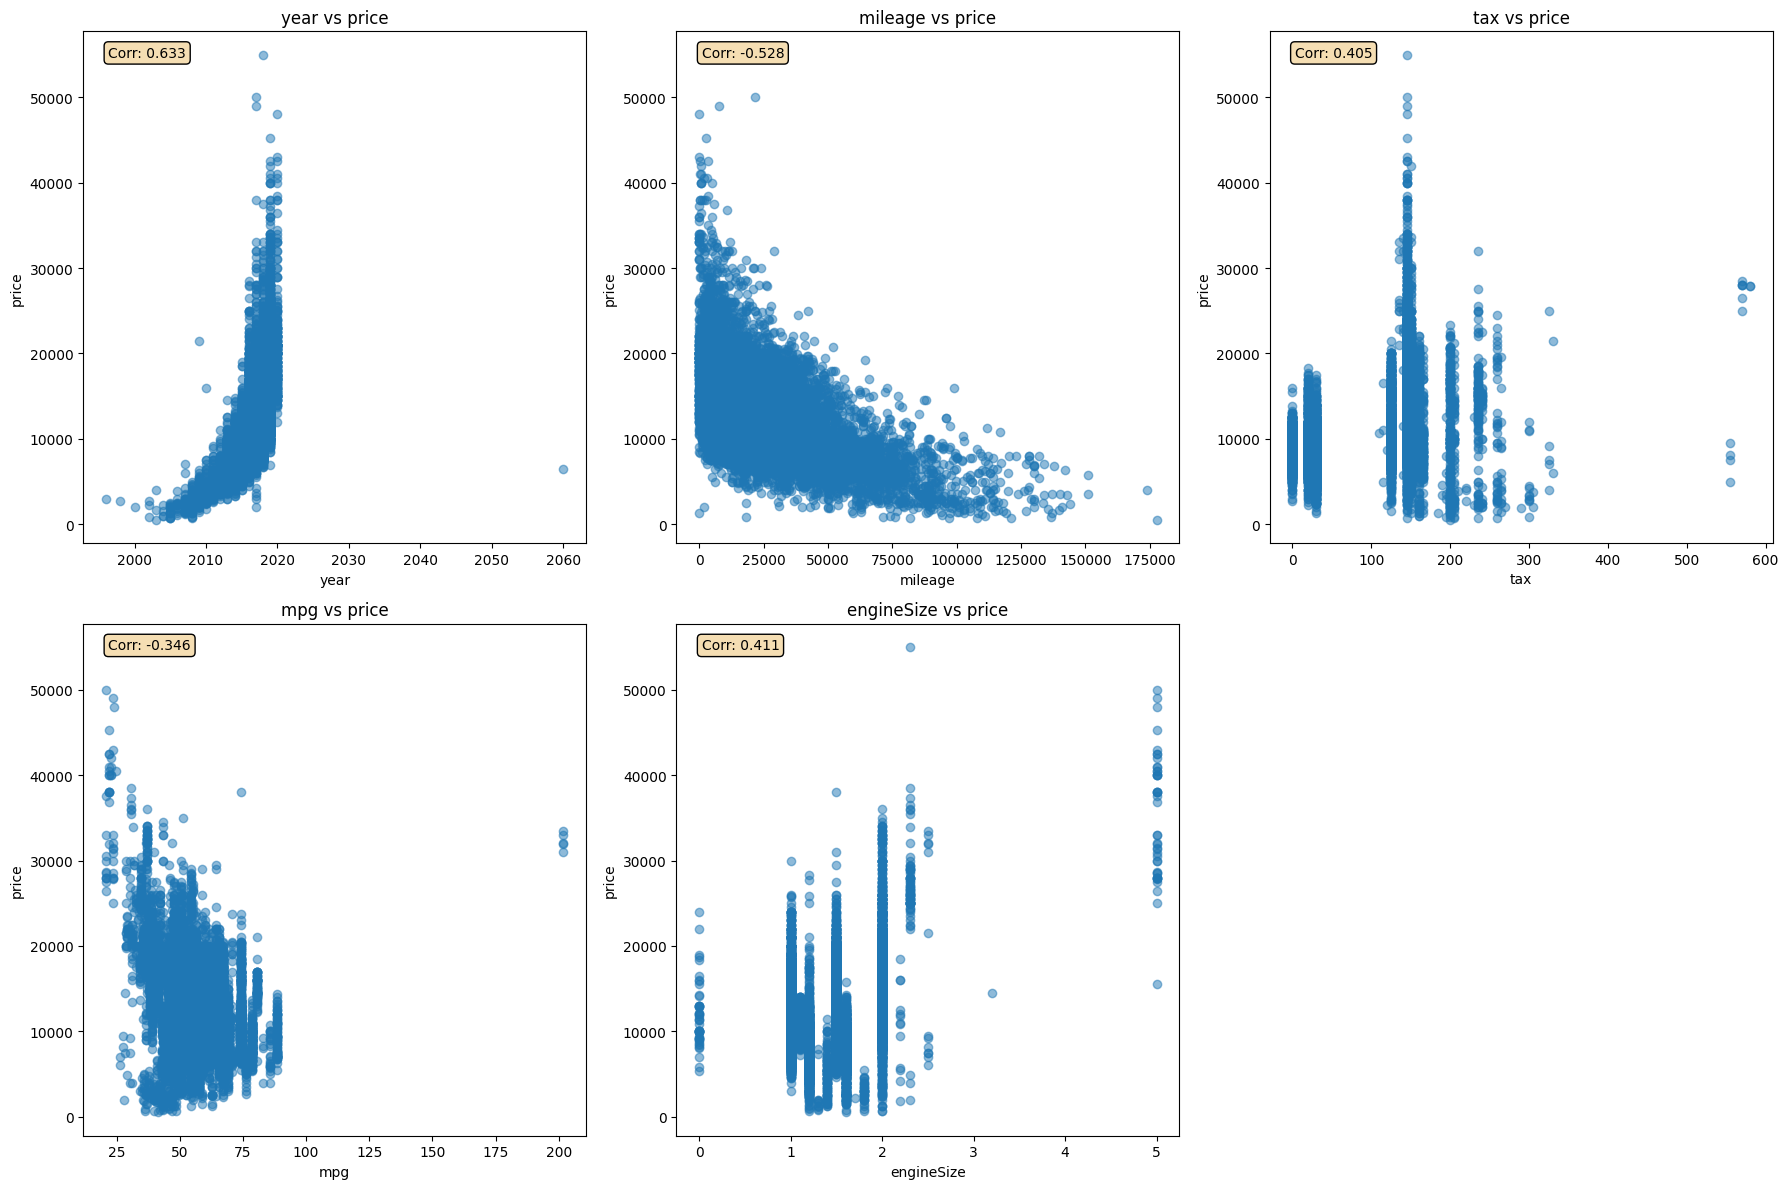

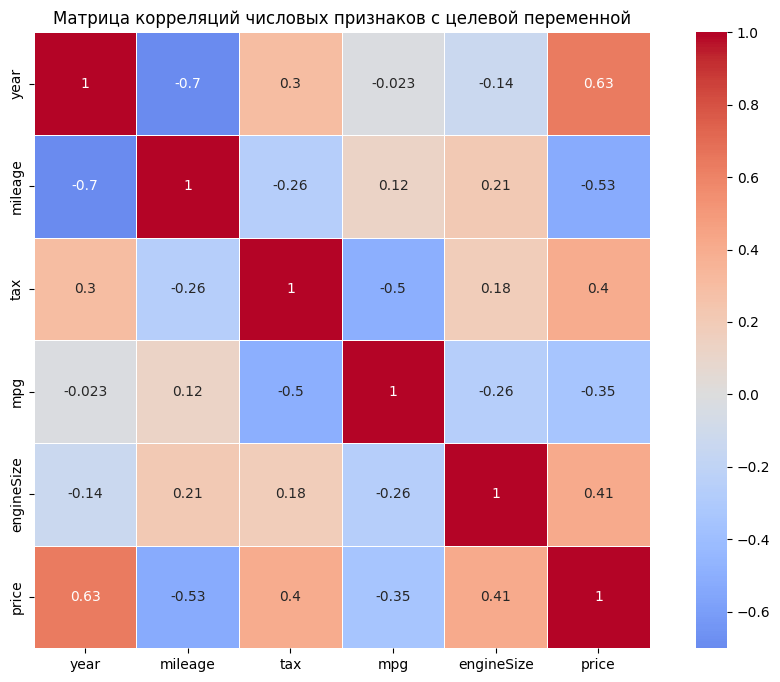

In [ ]:
target = 'price'

numeric_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    if i < len(axes):
        axes[i].scatter(df_scaled[feature], df_scaled[target], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(target)
        axes[i].set_title(f'{feature} vs {target}')
        correlation = df_scaled[feature].corr(df_scaled[target])
        axes[i].text(0.05, 0.95, f'Corr: {correlation:.3f}', transform=axes[i].transAxes, bbox=dict(boxstyle="round", facecolor='wheat'))

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
correlation_matrix = df_scaled[numeric_features + [target]].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Матрица корреляций числовых признаков с целевой переменной')
plt.show()

In [ ]:
from scipy.stats import f_oneway

categorical_encoded = ['model_encoded', 'fuelType_encoded', 
                    'transmission_Automatic', 'transmission_Manual', 'transmission_Semi-Auto']

print("ANOVA анализ связи категориальных признаков с ценой:")
for feature in categorical_encoded:
    if feature in df_scaled.columns:
        groups = [group for name, group in df_scaled.groupby(feature)[target]]
        f_stat, p_value = f_oneway(*groups)
        print(f"{feature}: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")

ANOVA анализ связи категориальных признаков с ценой:
model_encoded: F-statistic = 550.7941, p-value = 0.0000
fuelType_encoded: F-statistic = 213.4121, p-value = 0.0000
transmission_Automatic: F-statistic = 804.2430, p-value = 0.0000
transmission_Manual: F-statistic = 1272.8895, p-value = 0.0000
transmission_Semi-Auto: F-statistic = 360.6565, p-value = 0.0000


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calculate_vif(df, features):
    X = add_constant(df[features])
    vif_data = pd.DataFrame()
    vif_data['Feature'] = X.columns
    vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_data

vif_features = ['year', 'mileage', 'tax', 'mpg', 'engineSize', 'model_encoded', 'fuelType_encoded']
vif_results = calculate_vif(df_scaled, vif_features)
print("VIF анализ мультиколлинеарности:")
print(vif_results)

VIF анализ мультиколлинеарности:
            Feature           VIF
0             const  2.158407e+06
1              year  2.215777e+00
2           mileage  2.142137e+00
3               tax  1.522792e+00
4               mpg  2.243122e+00
5        engineSize  3.135287e+00
6     model_encoded  1.944334e+00
7  fuelType_encoded  3.089808e+00

Интерпретация VIF:
VIF < 5: слабая мультиколлинеарность
5 ≤ VIF < 10: умеренная мультиколлинеарность
VIF ≥ 10: сильная мультиколлинеарность


In [22]:
def analyze_feature_significance(df, target):
    """
    Комплексный анализ значимости признаков
    """
    feature_analysis = {}
    
    # Числовые признаки - корреляция с целевой переменной
    numeric_features = df.select_dtypes(include=[np.number]).columns
    numeric_features = [f for f in numeric_features if f != target]
    
    for feature in numeric_features:
        correlation = df[feature].corr(df[target])
        feature_analysis[feature] = {
            'type': 'numeric',
            'correlation': abs(correlation),
            'importance': abs(correlation)
        }
    
    # Анализ потенциальной утечки данных
    suspicious_features = []
    for feature in df.columns:
        if feature != target:
            # Признаки, которые могут содержать информацию о будущем
            if 'future' in feature.lower() or 'target' in feature.lower():
                suspicious_features.append(feature)
            # Слишком высокая корреляция может указывать на утечку
            if feature in feature_analysis and feature_analysis[feature]['correlation'] > 0.9:
                suspicious_features.append(feature)
    
    print("Самые информативные признаки:")
    sorted_features = sorted(feature_analysis.items(), 
                           key=lambda x: x[1]['importance'], reverse=True)
    for feature, info in sorted_features[:10]:
        print(f"  {feature}: {info['importance']:.4f}")
    
    print("\nПризнаки, вызывающие подозрение на утечку:")
    print(suspicious_features)
    
    return feature_analysis, suspicious_features

feature_analysis, suspicious_features = analyze_feature_significance(df_scaled, target)

Самые информативные признаки:
  price_clean: 0.9887
  price_scaled: 0.9807
  year_clean: 0.6518
  model_encoded: 0.6433
  year: 0.6325
  year_scaled: 0.6271
  mileage_scaled: 0.5687
  mileage_clean: 0.5353
  mileage: 0.5284
  engineSize: 0.4107

Признаки, вызывающие подозрение на утечку:
['price_clean', 'price_scaled']


In [28]:
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from sklearn.utils import resample
import warnings

def analyze_and_balance_target(df, target_column, min_samples=10):
    """
    Анализ и балансировка целевой переменной с обработкой редких классов
    """
    # Анализ распределения целевой переменной
    target_counts = df[target_column].value_counts()
    print("Распределение целевой переменной:")
    print(target_counts)
    
    # Визуализация до балансировки
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    target_counts.plot(kind='bar', color='skyblue')
    plt.title('Распределение целевой переменной ДО балансировки')
    plt.xlabel('Класс')
    plt.ylabel('Количество')
    plt.xticks(rotation=45)
    
    # Проверяем, есть ли классы с недостаточным количеством образцов
    rare_classes = target_counts[target_counts < min_samples]
    if len(rare_classes) > 0:
        print(f"\n ВНИМАНИЕ: Найдены классы с малым количеством образцов (<{min_samples}):")
        for cls, count in rare_classes.items():
            print(f"   - {cls}: {count} образцов")
    
    X = df.drop(target_column, axis=1)
    y = df[target_column]
    
    # Выбор стратегии балансировки в зависимости от данных
    if len(target_counts) == 2:
        # Бинарная классификация - используем SMOTE
        print("\n Используем SMOTE для бинарной балансировки")
        smote = SMOTE(random_state=42, k_neighbors=min(5, min(target_counts) - 1))
        X_balanced, y_balanced = smote.fit_resample(X, y)
        
    elif min(target_counts) > 5:  # Все классы имеют достаточно образцов для SMOTE
        print("\n Используем SMOTE для мультиклассовой балансировки")
        smote = SMOTE(random_state=42, k_neighbors=min(5, min(target_counts) - 1))
        X_balanced, y_balanced = smote.fit_resample(X, y)
        
    else:
        # Есть классы с малым количеством образцов - используем комбинированный подход
        print("\n Используем комбинированный подход (RandomOverSampler + шум)")
        ros = RandomOverSampler(random_state=42)
        X_balanced, y_balanced = ros.fit_resample(X, y)
    
    # Добавляем шум к синтетическим наблюдениям (10-20% от std)
    print("\n Добавляем шум к синтетическим наблюдениям...")
    np.random.seed(42)
    
    # Определяем, какие образцы были добавлены при балансировке
    original_indices = range(len(X))
    synthetic_mask = ~pd.Series(X_balanced.index).isin(original_indices)
    
    if synthetic_mask.any():
        X_synthetic = X_balanced[synthetic_mask].select_dtypes(include=[np.number])
        
        for col in X_synthetic.columns:
            if X_synthetic[col].std() > 0:  # Избегаем деления на 0
                noise_std = 0.15 * X_synthetic[col].std()  # 15% от стандартного отклонения
                noise = np.random.normal(0, noise_std, size=len(X_synthetic))
                X_balanced.loc[synthetic_mask, col] = X_synthetic[col] + noise
                print(f"   - Добавлен шум к {col} (std={noise_std:.4f})")
    
    # Визуализация после балансировки
    balanced_counts = pd.Series(y_balanced).value_counts()
    
    plt.subplot(1, 2, 2)
    balanced_counts.plot(kind='bar', color='lightcoral')
    plt.title('Распределение целевой переменной ПОСЛЕ балансировки')
    plt.xlabel('Класс')
    plt.ylabel('Количество')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Статистика балансировки
    print(f"\n СТАТИСТИКА БАЛАНСИРОВКИ:")
    print(f"   До: {dict(target_counts)}")
    print(f"   После: {dict(balanced_counts)}")
    print(f"   Добавлено синтетических образцов: {len(X_balanced) - len(X)}")
    
    return X_balanced, y_balanced

In [ ]:
def smart_balance_analysis(df, target_column):
    """
    Умный анализ и выбор стратегии балансировки
    """
    target_counts = df[target_column].value_counts()
    n_classes = len(target_counts)
    min_samples = min(target_counts)
    
    print("=" * 50)
    print("АНАЛИЗ ДИСБАЛАНСА КЛАССОВ")
    print("=" * 50)
    print(f"Количество классов: {n_classes}")
    print(f"Минимальное количество образцов в классе: {min_samples}")
    print(f"Максимальное количество образцов в классе: {max(target_counts)}")
    print(f"Коэффициент дисбаланса: {max(target_counts)/min_samples:.2f}:1")
    
    # Визуализация дисбаланса
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%')
    plt.title('Распределение классов')

    plt.subplot(1, 2, 2)
    plt.bar(range(len(target_counts)), target_counts.values)
    plt.xticks(range(len(target_counts)), target_counts.index, rotation=45)
    plt.title('Абсолютные значения')
    plt.ylabel('Количество образцов')

    plt.tight_layout()
    plt.show()
    
    # Рекомендация по стратегии
    print("\nРЕКОМЕНДАЦИИ ПО БАЛАНСИРОВКЕ:")
    
    if n_classes == 2:
        if min_samples >= 6:
            print("SMOTE - оптимальный выбор для бинарной классификации")
        else:
            print("RandomOverSampler - из-за малого количества образцов в миноритарном классе")
    else:
        if min_samples >= 6:
            print("SMOTE - подходит для мультиклассовой классификации")
        elif min_samples >= 3:
            print("ADASYN - адаптивный метод для сложных распределений")
        else:
            print("RandomOverSampler - единственный вариант для очень редких классов")
    
    return target_counts

АНАЛИЗ ДИСБАЛАНСА КЛАССОВ
Количество классов: 5
Минимальное количество образцов в классе: 5
Максимальное количество образцов в классе: 9049
Коэффициент дисбаланса: 1809.80:1


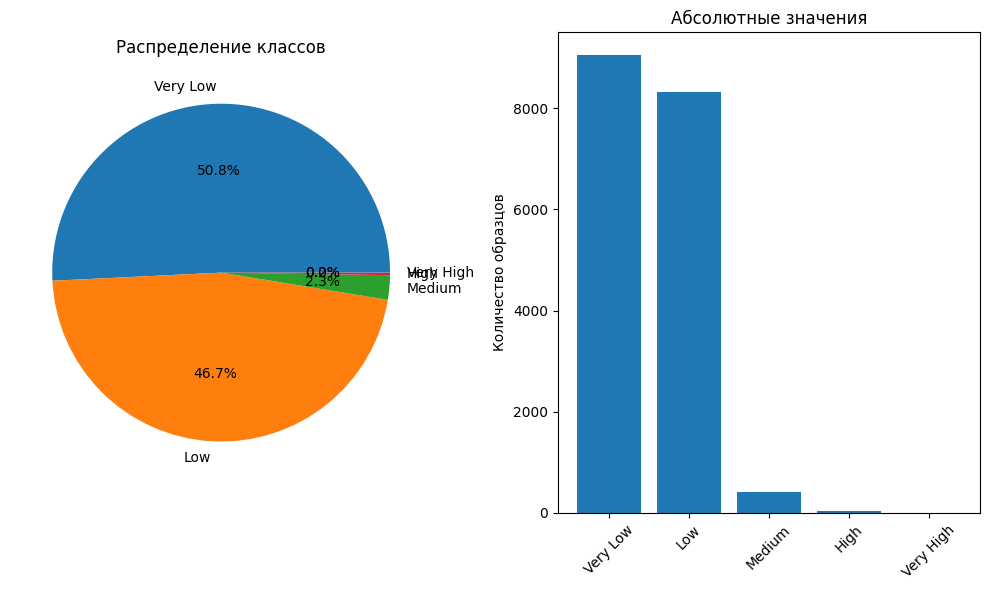


РЕКОМЕНДАЦИИ ПО БАЛАНСИРОВКЕ:
ADASYN - адаптивный метод для сложных распределений
Распределение целевой переменной:
price_category
Very Low     9049
Low          8316
Medium        416
High           38
Very High       5
Name: count, dtype: int64

 ВНИМАНИЕ: Найдены классы с малым количеством образцов (<10):
   - Very High: 5 образцов

 Используем комбинированный подход (RandomOverSampler + шум)

 Добавляем шум к синтетическим наблюдениям...
   - Добавлен шум к year (std=0.1548)
   - Добавлен шум к price (std=1587.2245)
   - Добавлен шум к mileage (std=1070.6031)
   - Добавлен шум к tax (std=5.4282)
   - Добавлен шум к mpg (std=3.3353)
   - Добавлен шум к engineSize (std=0.2277)
   - Добавлен шум к model_encoded (std=1343.9964)
   - Добавлен шум к fuelType_encoded (std=0.0767)
   - Добавлен шум к price_clean (std=305.6540)
   - Добавлен шум к mileage_clean (std=1070.1221)
   - Добавлен шум к year_clean (std=0.1548)
   - Добавлен шум к tax_clean (std=1.9695)
   - Добавлен шум к mpg_cle

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_9396\1872495841.py:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[37437.67215478 41910.96624996 37890.99785785 ... 47422.62554137
 54913.37228693 53028.70825395]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_balanced.loc[synthetic_mask, col] = X_synthetic[col] + noise
C:\Users\Пользователь\AppData\Local\Temp\ipykernel_9396\1872495841.py:66: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[-0.02568611  0.04292444 -0.09450258 ...  0.00383561 -0.03798072
  0.04043653]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_balanced.loc[synthetic_mask, col] = X_synthetic[col] + noise


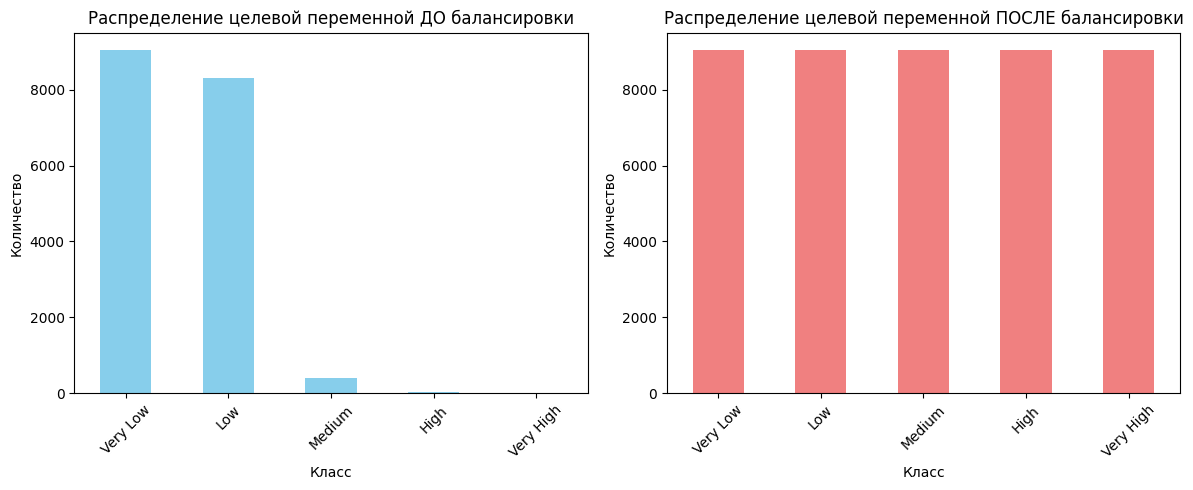


 СТАТИСТИКА БАЛАНСИРОВКИ:
   До: {'Very Low': np.int64(9049), 'Low': np.int64(8316), 'Medium': np.int64(416), 'High': np.int64(38), 'Very High': np.int64(5)}
   После: {'Very Low': np.int64(9049), 'Low': np.int64(9049), 'Medium': np.int64(9049), 'High': np.int64(9049), 'Very High': np.int64(9049)}
   Добавлено синтетических образцов: 27421
Балансировка успешно завершена!


In [34]:
# Сначала анализируем дисбаланс
target_counts = smart_balance_analysis(df_scaled, 'price_category')

# Затем применяем балансировку
try:
    X_balanced, y_balanced = analyze_and_balance_target(df_scaled, 'price_category')
    print("Балансировка успешно завершена!")
    
except Exception as e:
    print(f"Ошибка при балансировке: {e}")
    print("\nПробуем альтернативный подход...")
    
    # Резервный метод - ручная балансировка
    def manual_balance(df, target_column):
        """Ручная балансировка для сложных случаев"""
        target_counts = df[target_column].value_counts()
        max_size = max(target_counts)
        
        balanced_dfs = []
        for class_name in target_counts.index:
            class_df = df[df[target_column] == class_name]
            if len(class_df) < max_size:
                # Дублируем существующие данные
                n_samples_needed = max_size - len(class_df)
                additional_samples = class_df.sample(n=n_samples_needed, 
                                                   replace=True, 
                                                   random_state=42)
                # Добавляем шум к дублированным данным
                numeric_cols = additional_samples.select_dtypes(include=[np.number]).columns
                for col in numeric_cols:
                    noise = np.random.normal(0, 0.1 * additional_samples[col].std(), 
                                           size=len(additional_samples))
                    additional_samples[col] = additional_samples[col] + noise
                
                balanced_class_df = pd.concat([class_df, additional_samples])
            else:
                balanced_class_df = class_df
                
            balanced_dfs.append(balanced_class_df)
        
        return pd.concat(balanced_dfs, ignore_index=True)
    
    df_balanced = manual_balance(df_scaled, 'price_category')
    X_balanced = df_balanced.drop('price_category', axis=1)
    y_balanced = df_balanced['price_category']
    
    print("Ручная балансировка завершена!")

c:\Users\Пользователь\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\Пользователь\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Пользователь\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


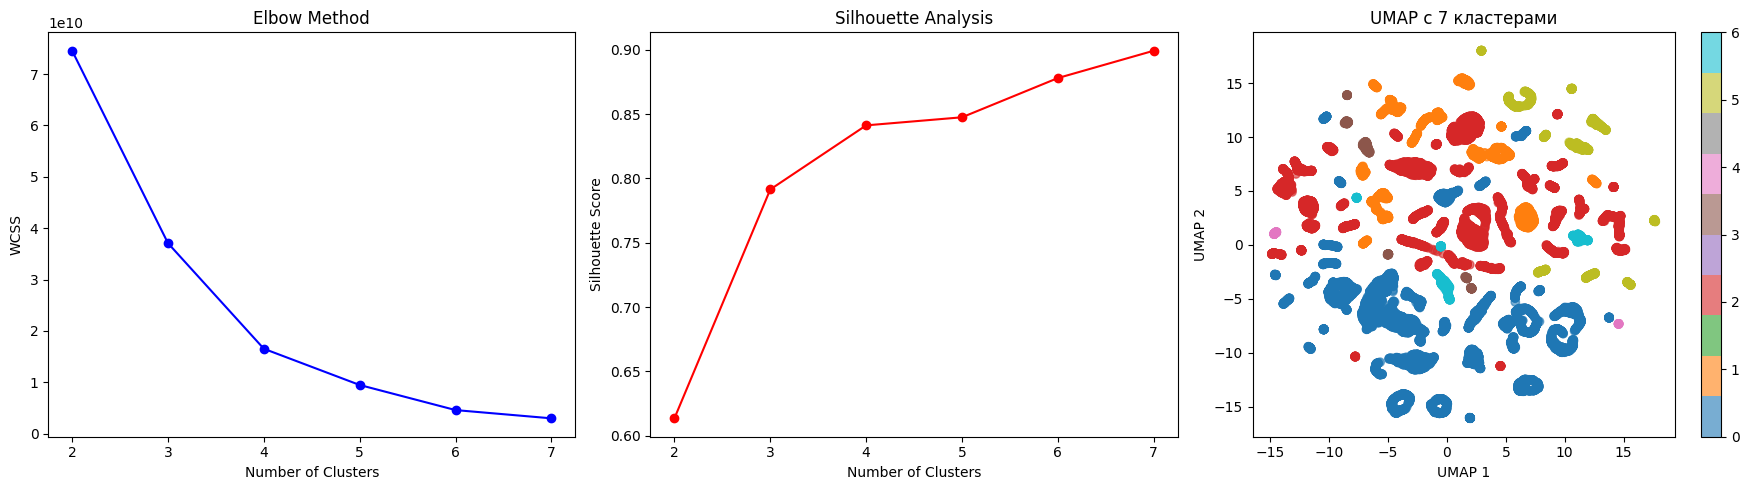

Оптимальное число кластеров: 7

Характеристики кластеров:
                 mean          std  count
cluster                                  
0        10190.414020  2851.201169   7304
1        15792.409974  3624.349921   2266
2        12982.465116  4365.349873   6235
3        22121.365439  4556.091406    353
4        34631.263158  6565.341384     57
5         7836.546458  2219.447120   1087
6        17736.848659  5223.097145    522


In [41]:
import umap.umap_ as umap
def advanced_cluster_analysis(df, target_column='price'):
    """
    Продвинутый кластерный анализ с интерпретацией
    """
    # Подготовка данных
    features_for_clustering = [col for col in df.columns if '_scaled' in col or '_encoded' in col]
    X = df[features_for_clustering].fillna(0)
    
    # KMeans для определения оптимального числа кластеров
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
    
    # Определение оптимального числа кластеров
    wcss = []
    silhouette_scores = []
    k_range = range(2, 8)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(X)
        wcss.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))
    
    # Визуализация elbow method и silhouette scores
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Elbow method
    axes[0].plot(k_range, wcss, 'bo-')
    axes[0].set_xlabel('Number of Clusters')
    axes[0].set_ylabel('WCSS')
    axes[0].set_title('Elbow Method')
    
    # Silhouette scores
    axes[1].plot(k_range, silhouette_scores, 'ro-')
    axes[1].set_xlabel('Number of Clusters')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].set_title('Silhouette Analysis')
    
    # Выбираем оптимальное k
    optimal_k = k_range[np.argmax(silhouette_scores)]
    kmeans_optimal = KMeans(n_clusters=optimal_k, random_state=42)
    cluster_labels = kmeans_optimal.fit_predict(X)
    
    # UMAP с кластерами
    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X)
    
    scatter = axes[2].scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_labels, 
                            cmap='tab10', alpha=0.6)
    axes[2].set_title(f'UMAP с {optimal_k} кластерами')
    axes[2].set_xlabel('UMAP 1')
    axes[2].set_ylabel('UMAP 2')
    plt.colorbar(scatter, ax=axes[2])
    
    plt.tight_layout()
    plt.show()
    
    # Анализ характеристик кластеров
    df_clustered = df.copy()
    df_clustered['cluster'] = cluster_labels
    
    print(f"Оптимальное число кластеров: {optimal_k}")
    print("\nХарактеристики кластеров:")
    cluster_analysis = df_clustered.groupby('cluster')[target_column].agg(['mean', 'std', 'count'])
    print(cluster_analysis)
    
    return df_clustered, cluster_labels

# Запуск углубленного кластерного анализа
df_clustered, clusters = advanced_cluster_analysis(df_scaled)